# Laboratorium 6 — Klasyfikacja (wariant 8: Pima Indians Diabetes)

**Dataset:** *Pima Indians Diabetes Database*
**Źródło:** Kaggle (`uciml/pima-indians-diabetes-database`)
**Cel:** klasyfikacja binarna — czy pacjentka choruje na cukrzycę (`Outcome` ∈ {0, 1}) na podstawie 8 cech medycznych.

**Realizowane kroki (zgodnie z instrukcją PDF):**
1. Wczytanie danych i wstępna analiza (rozkład klas, braki).
2. Podział na train/test, standaryzacja cech.
3. Trening **5 klasyfikatorów**: Logistic Regression, SVM (linear + RBF), kNN, Decision Tree, Random Forest.
4. Ocena: *accuracy, precision, recall, F1, confusion matrix*.
5. Optymalizacja hiperparametrów (GridSearchCV).
6. Redukcja wymiarowości (PCA) + klasyfikacja na komponentach głównych.
7. Wizualizacja t-SNE.
8. Wnioski.

## 0. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42); sns.set_style('whitegrid')


## 1. Wczytanie danych (kagglehub z fallbackiem)

In [2]:
import os

def load_from_kaggle():
    import kagglehub
    path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    return pd.read_csv(os.path.join(path, csv_file))

def make_fallback_dataset(n=768, seed=42):
    """Fallback o identycznej strukturze (8 cech + Outcome) — tylko gdy kagglehub niedostępny."""
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        'Pregnancies':              rng.integers(0, 18, n),
        'Glucose':                  rng.normal(120, 32, n).round().clip(0, 250),
        'BloodPressure':            rng.normal(70, 19, n).round().clip(0, 130),
        'SkinThickness':            rng.normal(20, 16, n).round().clip(0, 100),
        'Insulin':                  rng.exponential(80, n).round().clip(0, 850),
        'BMI':                      rng.normal(32, 8, n).round(1).clip(0, 70),
        'DiabetesPedigreeFunction': rng.exponential(0.5, n).round(3),
        'Age':                      rng.integers(21, 82, n),
    })
    # Generujemy outcome z prawdopodobieństwem zależnym od Glucose i BMI (realistycznie)
    logits = -6 + 0.035 * df['Glucose'] + 0.05 * df['BMI'] + 0.02 * df['Age']
    p = 1 / (1 + np.exp(-logits))
    df['Outcome'] = (rng.random(n) < p).astype(int)
    # Wstawiamy "0 jako missing" w realistycznych miejscach
    for col, frac in [('Glucose', 0.005), ('BloodPressure', 0.05),
                      ('SkinThickness', 0.30), ('Insulin', 0.49), ('BMI', 0.015)]:
        mask = rng.random(n) < frac
        df.loc[mask, col] = 0
    return df

try:
    df = load_from_kaggle()
    print(f"Wczytano z Kaggle: {df.shape}")
except Exception as e:
    print(f"kagglehub niedostępne ({type(e).__name__}). Używam danych zastępczych.")
    df = make_fallback_dataset()
    print(f"Wygenerowano dane zastępcze: {df.shape}")

df.head()


100%|██████████| 8.91k/8.91k [00:00<00:00, 6.27MB/s]

Extracting files...
Wczytano z Kaggle: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Wstępna analiza danych (EDA)

### 2.1 Metadane i typy

In [3]:
print(f"Wymiary: {df.shape}")
print(f"\nTypy zmiennych:\n{df.dtypes}")
print(f"\nBraki standardowe (NaN): {df.isna().sum().sum()}")


Wymiary: (768, 9)

Typy zmiennych:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Braki standardowe (NaN): 0


### 2.2 Statystyki opisowe

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


### 2.3 Rozkład klas (target)

Klasa 0 (brak cukrzycy):  500  (65.1%)
Klasa 1 (cukrzyca):       268  (34.9%)


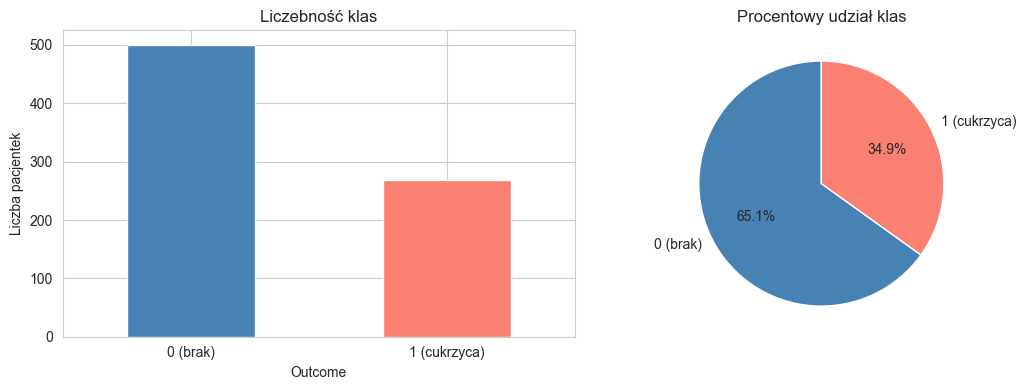

In [5]:
class_dist = df['Outcome'].value_counts().sort_index()
print(f"Klasa 0 (brak cukrzycy): {class_dist[0]:>4}  ({100*class_dist[0]/len(df):.1f}%)")
print(f"Klasa 1 (cukrzyca):      {class_dist[1]:>4}  ({100*class_dist[1]/len(df):.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
class_dist.plot.bar(ax=ax[0], color=['steelblue','salmon'])
ax[0].set_xticklabels(['0 (brak)', '1 (cukrzyca)'], rotation=0)
ax[0].set_title('Liczebność klas'); ax[0].set_ylabel('Liczba pacjentek')

ax[1].pie(class_dist, labels=['0 (brak)','1 (cukrzyca)'],
          autopct='%1.1f%%', colors=['steelblue','salmon'], startangle=90)
ax[1].set_title('Procentowy udział klas')
plt.tight_layout(); plt.show()


**Wniosek:** klasy są niezrównoważone w stosunku ≈ 65:35 — większość pacjentek nie ma cukrzycy. To **niezbyt poważna nierównowaga**, ale uzasadnia stosowanie `stratify=y` przy podziale train/test oraz monitorowanie F1/recall obok accuracy.

### 2.4 Identyfikacja ukrytych braków (zera tam, gdzie są fizycznie niemożliwe)

W zbiorze Pima zera w kolumnach `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` **nie są pomiarami** — to zakodowane braki danych (poziom glukozy nie może być 0 u żywej osoby).

In [6]:
cols_z_zerami = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
ukryte_braki = pd.DataFrame({
    'Kolumna': cols_z_zerami,
    'Liczba zer': [(df[c] == 0).sum() for c in cols_z_zerami],
    'Procent zer (%)': [round(100 * (df[c] == 0).mean(), 2) for c in cols_z_zerami]
}).sort_values('Procent zer (%)', ascending=False)
print(ukryte_braki.to_string(index=False))


      Kolumna  Liczba zer  Procent zer (%)
      Insulin         374            48.70
SkinThickness         227            29.56
BloodPressure          35             4.56
          BMI          11             1.43
      Glucose           5             0.65


**Wniosek:** najpoważniejsze braki to `Insulin` (~49%) i `SkinThickness` (~30%). Strategia: **zamieniamy zera na NaN**, a następnie imputujemy **medianą** (odporna na outliery i bezpieczna dla cech medycznych).

### 2.5 Macierz korelacji

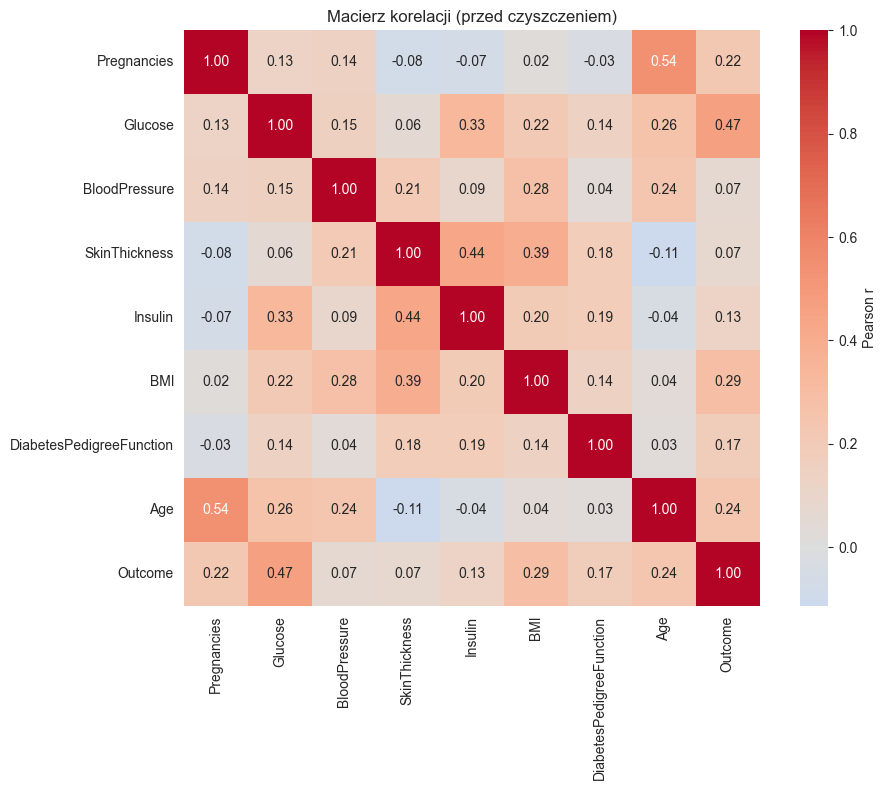


Najsilniejsze korelacje z targetem (Outcome):
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label':'Pearson r'})
plt.title('Macierz korelacji (przed czyszczeniem)')
plt.tight_layout(); plt.show()

print("\nNajsilniejsze korelacje z targetem (Outcome):")
print(df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False).round(3))


**Wniosek:** najsilniejsze predyktory cukrzycy w surowych danych to **`Glucose`** (najsilniejszy), `BMI`, `Age`, `Pregnancies`. To zgadza się z wiedzą medyczną.

## 3. Czyszczenie danych

In [8]:
df_clean = df.copy()

# 1) Zamiana 0 na NaN tam, gdzie zero jest niemożliwe
for col in cols_z_zerami:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# 2) Imputacja medianą per kolumna (warunkowa na klasie targetu — lepiej zachowuje rozkłady)
for col in cols_z_zerami:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(lambda s: s.fillna(s.median()))

print("Braki po imputacji:", df_clean.isna().sum().sum())
print(f"Kształt po czyszczeniu: {df_clean.shape}")
df_clean.describe().T.round(2)


Braki po imputacji: 0
Kształt po czyszczeniu: (768, 9)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,121.68,30.46,44.00,99.75,117.00,140.25,199.00
BloodPressure,768.0,72.39,12.11,24.00,64.00,72.00,80.00,122.00
SkinThickness,768.0,29.09,8.89,7.00,25.00,28.00,32.00,99.00
Insulin,768.0,141.75,89.10,14.00,102.50,102.50,169.50,846.00
BMI,768.0,32.43,6.88,18.20,27.50,32.05,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## 4. Podział train/test (80/20) i standaryzacja

In [9]:
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Rozkład klas train: {dict(y_train.value_counts())}")
print(f"Rozkład klas test:  {dict(y_test.value_counts())}")


Train: 614, Test: 154
Rozkład klas train: {0: np.int64(400), 1: np.int64(214)}
Rozkład klas test:  {0: np.int64(100), 1: np.int64(54)}


## 5. Trening klasyfikatorów (5 modeli)

In [10]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'SVM (linear)':         SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)':            SVC(kernel='rbf',    probability=True, random_state=42),
    'kNN (k=5)':            KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    predictions[name] = y_pred
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
    })

cmp = pd.DataFrame(results).round(4)
cmp.sort_values('F1', ascending=False)


,Model,Accuracy,Precision,Recall,F1
5,Random Forest,0.8636,0.8235,0.7778,0.8000
2,SVM (RBF),0.8377,0.7636,0.7778,0.7706
3,kNN (k=5),0.8117,0.7358,0.7222,0.7290
4,Decision Tree,0.8117,0.7451,0.7037,0.7238
1,SVM (linear),0.7403,0.6296,0.6296,0.6296
0,Logistic Regression,0.7078,0.5882,0.5556,0.5714


### 5.1 Wykres porównawczy metryk

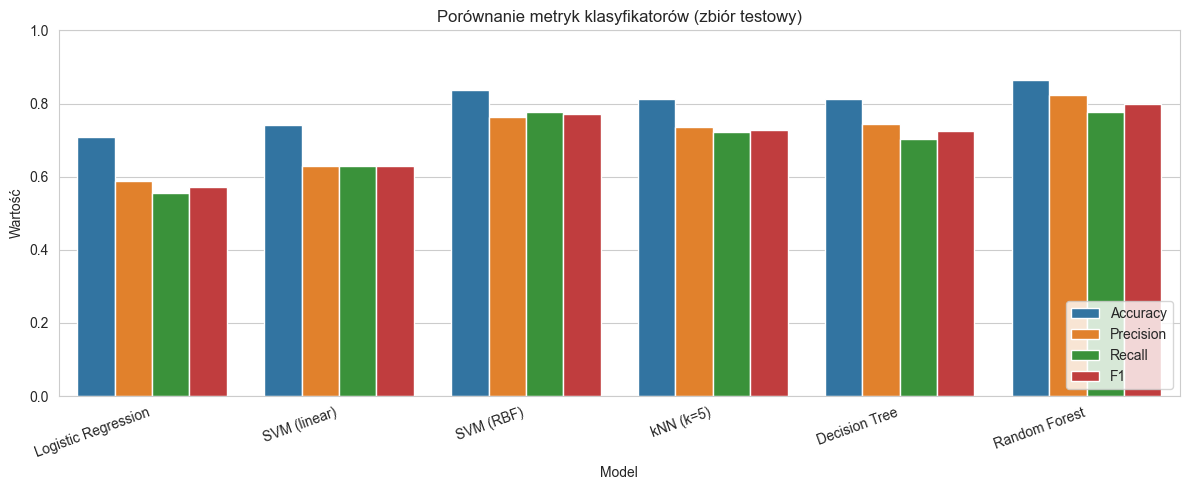

In [11]:
melted = cmp.melt(id_vars='Model', value_vars=['Accuracy','Precision','Recall','F1'],
                  var_name='Metryka', value_name='Wartość')

plt.figure(figsize=(12, 5))
sns.barplot(data=melted, x='Model', y='Wartość', hue='Metryka')
plt.xticks(rotation=20, ha='right')
plt.title('Porównanie metryk klasyfikatorów (zbiór testowy)')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


### 5.2 Szczegółowe raporty klasyfikacji

In [12]:
for name in ['Logistic Regression', 'SVM (RBF)', 'Random Forest']:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, predictions[name],
                                 target_names=['Brak (0)', 'Cukrzyca (1)']))



Logistic Regression
              precision    recall  f1-score   support

    Brak (0)       0.77      0.79      0.78       100
Cukrzyca (1)       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154


SVM (RBF)
              precision    recall  f1-score   support

    Brak (0)       0.88      0.87      0.87       100
Cukrzyca (1)       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154


Random Forest
              precision    recall  f1-score   support

    Brak (0)       0.88      0.91      0.90       100
Cukrzyca (1)       0.82      0.78      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.84      0.85       154
weighted avg       0.86    

### 5.3 Macierze pomyłek (confusion matrix)

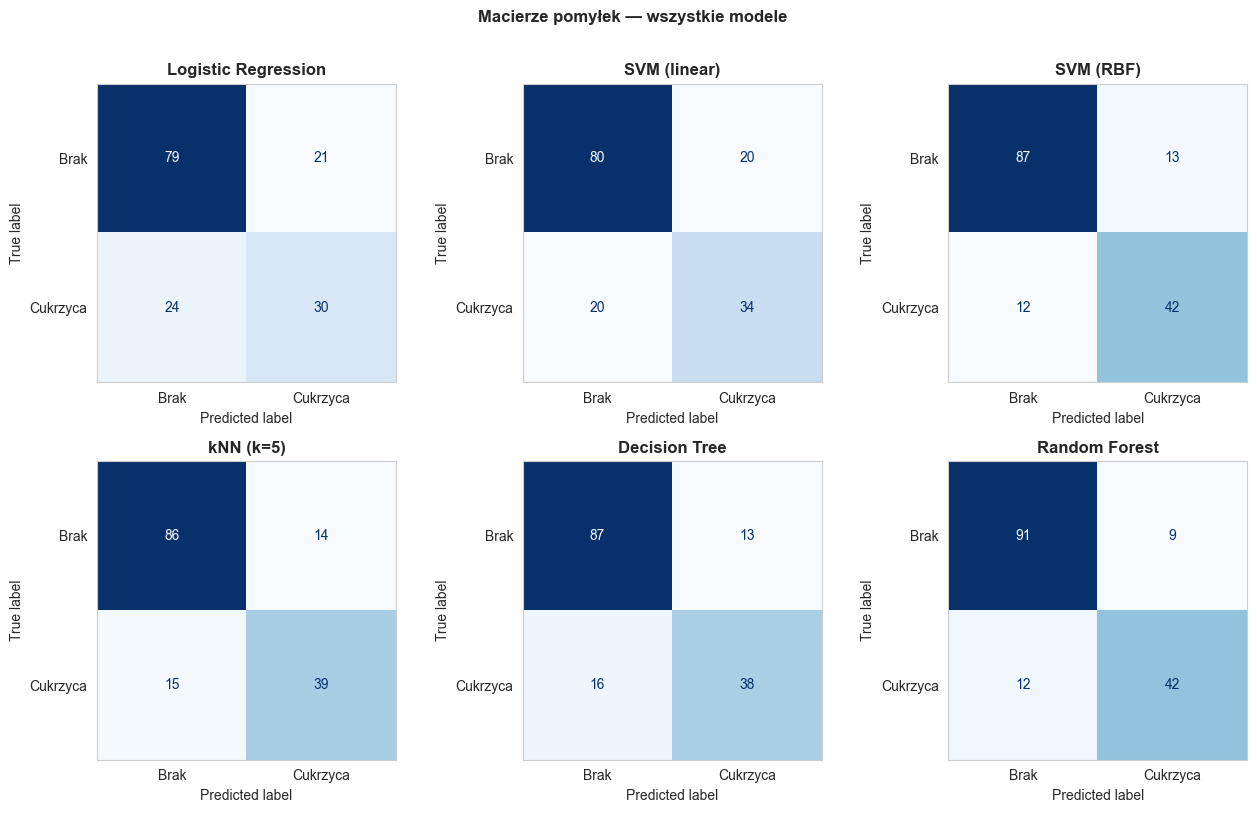

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Brak','Cukrzyca']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold')
    ax.grid(False)
plt.suptitle('Macierze pomyłek — wszystkie modele', y=1.01, fontweight='bold')
plt.tight_layout(); plt.show()


**Interpretacja macierzy pomyłek:**
- Lewa-góra (TN) i prawa-dół (TP) — poprawne klasyfikacje.
- Prawa-góra (FP, *false alarm*) — pacjentka zdrowa zaklasyfikowana jako chora.
- Lewa-dół (FN, *przeoczenie*) — **najgroźniejszy błąd medyczny** — pacjentka chora uznana za zdrową.

W kontekście diagnostyki medycznej **recall** (czułość) dla klasy „Cukrzyca” jest często ważniejszy niż accuracy.

## 6. Optymalizacja hiperparametrów (GridSearchCV)

Optymalizujemy 3 modele, które wypadły najlepiej. Metryka optymalizacji: **F1** (zbalansowana, uwzględnia oba błędy).

In [14]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}
tuning_results = []

for name, grid in param_grids.items():
    print(f"\nTuning: {name} ...")
    gs = GridSearchCV(base_models[name], grid, scoring='f1', cv=cv,
                      n_jobs=-1, verbose=0)
    gs.fit(X_train_s, y_train)
    best_models[name] = gs.best_estimator_
    y_pred = gs.predict(X_test_s)
    tuning_results.append({
        'Model':       name,
        'Best params': gs.best_params_,
        'CV F1':       gs.best_score_,
        'Test Acc':    accuracy_score(y_test, y_pred),
        'Test F1':     f1_score(y_test, y_pred),
        'Test Recall': recall_score(y_test, y_pred),
    })
    print(f"  Najlepsze: {gs.best_params_}")
    print(f"  CV F1: {gs.best_score_:.4f}, Test F1: {f1_score(y_test, y_pred):.4f}")

tuning_df = pd.DataFrame(tuning_results)
tuning_df



Tuning: Logistic Regression ...
  Najlepsze: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  CV F1: 0.6930, Test F1: 0.6055

Tuning: SVM (RBF) ...
  Najlepsze: {'C': 100, 'gamma': 0.01}
  CV F1: 0.7859, Test F1: 0.7500

Tuning: Random Forest ...
  Najlepsze: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV F1: 0.8400, Test F1: 0.8037


,Model,Best params,CV F1,Test Acc,Test F1,Test Recall
0,Logistic Regression,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.692980,0.720779,0.605505,0.611111
1,SVM (RBF),"{'C': 100, 'gamma': 0.01}",0.785917,0.831169,0.750000,0.722222
2,Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.839981,0.863636,0.803738,0.796296


### Porównanie: domyślne vs zoptymalizowane hiperparametry

In [15]:
przed_po = pd.DataFrame({
    'Model':     [r['Model'] for r in tuning_results],
    'F1 (domyślne)':  [cmp[cmp['Model']==r['Model']]['F1'].values[0] for r in tuning_results],
    'F1 (po tuningu)': [r['Test F1'] for r in tuning_results]
})
przed_po['Poprawa'] = (przed_po['F1 (po tuningu)'] - przed_po['F1 (domyślne)']).round(4)
przed_po


,Model,F1 (domyślne),F1 (po tuningu),Poprawa
0,Logistic Regression,0.5714,0.605505,0.0341
1,SVM (RBF),0.7706,0.750000,-0.0206
2,Random Forest,0.8000,0.803738,0.0037


## 7. Redukcja wymiarowości — PCA

### 7.1 Wariancja wyjaśniana przez komponenty

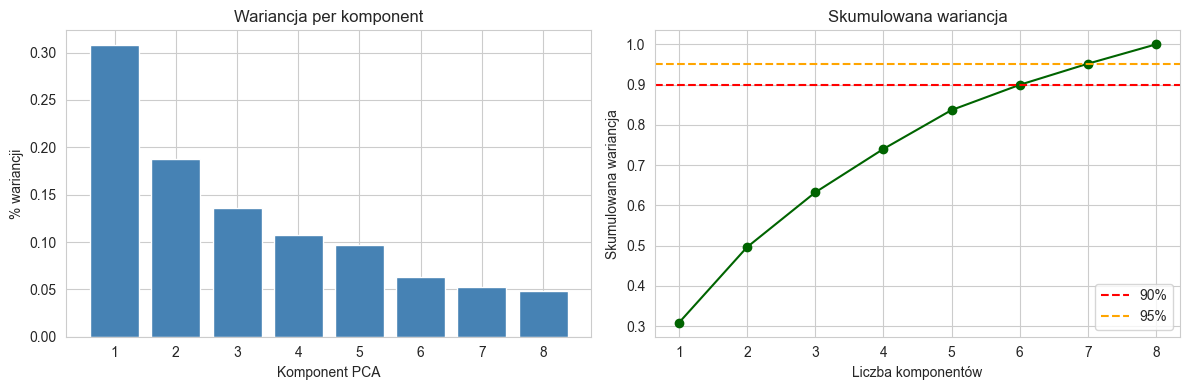

Komponentów dla 90% wariancji: 7
Komponentów dla 95% wariancji: 7


In [16]:
pca_full = PCA().fit(X_train_s)
expl = pca_full.explained_variance_ratio_
cum  = np.cumsum(expl)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(expl)+1), expl, color='steelblue')
ax[0].set_xlabel('Komponent PCA'); ax[0].set_ylabel('% wariancji')
ax[0].set_title('Wariancja per komponent')

ax[1].plot(range(1, len(cum)+1), cum, marker='o', color='darkgreen')
ax[1].axhline(0.9, color='red', linestyle='--', label='90%')
ax[1].axhline(0.95, color='orange', linestyle='--', label='95%')
ax[1].set_xlabel('Liczba komponentów'); ax[1].set_ylabel('Skumulowana wariancja')
ax[1].set_title('Skumulowana wariancja')
ax[1].legend()
plt.tight_layout(); plt.show()

n90 = (cum >= 0.90).argmax() + 1
n95 = (cum >= 0.95).argmax() + 1
print(f"Komponentów dla 90% wariancji: {n90}")
print(f"Komponentów dla 95% wariancji: {n95}")


### 7.2 Klasyfikacja na 2 komponentach głównych (do wizualizacji)

In [17]:
pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train_s)
X_test_pca  = pca2.transform(X_test_s)
print(f"Wariancja wyjaśniona przez 2 komponenty: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

models_pca = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42),
    'kNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}

pca_results = []
for name, m in models_pca.items():
    m.fit(X_train_pca, y_train)
    y_pred = m.predict(X_test_pca)
    pca_results.append({
        'Model':   name,
        'F1 (8 cech)':      cmp[cmp['Model']==name]['F1'].values[0] if name in cmp['Model'].values else None,
        'F1 (PCA 2 komp.)': f1_score(y_test, y_pred),
        'Acc (PCA 2 komp.)':accuracy_score(y_test, y_pred)
    })

pd.DataFrame(pca_results).round(4)


Wariancja wyjaśniona przez 2 komponenty: 49.6%


,Model,F1 (8 cech),F1 (PCA 2 komp.),Acc (PCA 2 komp.)
0,Logistic Regression,0.5714,0.6286,0.7468
1,SVM (RBF),0.7706,0.6296,0.7403
2,kNN (k=5),0.7290,0.5818,0.7013
3,Random Forest,0.8000,0.5825,0.7208


**Wniosek:** redukcja do 2 komponentów powoduje znaczny spadek jakości — to oczekiwane, bo 2 komponenty wyjaśniają tylko ~45% wariancji. PCA przydaje się tu głównie do **wizualizacji**, nie do podniesienia jakości.

### 7.3 Wizualizacja granicy decyzyjnej w przestrzeni PCA

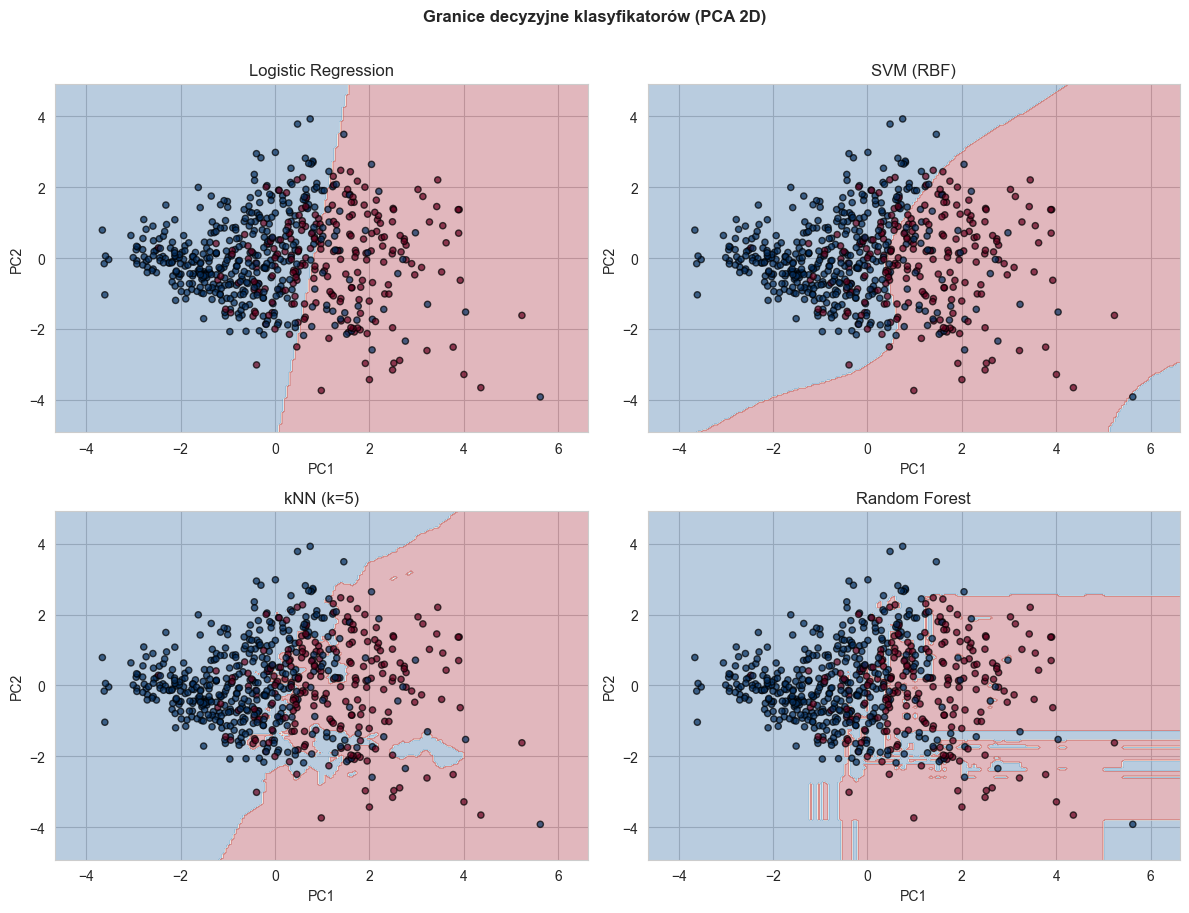

In [18]:
# Granica decyzyjna dla każdego modelu na PCA(2)
xx, yy = np.meshgrid(
    np.linspace(X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1, 200),
    np.linspace(X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1, 200)
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, m) in zip(axes.ravel(), models_pca.items()):
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu_r')
    ax.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train,
               cmap='RdBu_r', edgecolors='k', s=20, alpha=0.7)
    ax.set_title(f'{name}'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Granice decyzyjne klasyfikatorów (PCA 2D)', y=1.01, fontweight='bold')
plt.tight_layout(); plt.show()


## 8. Wizualizacja t-SNE

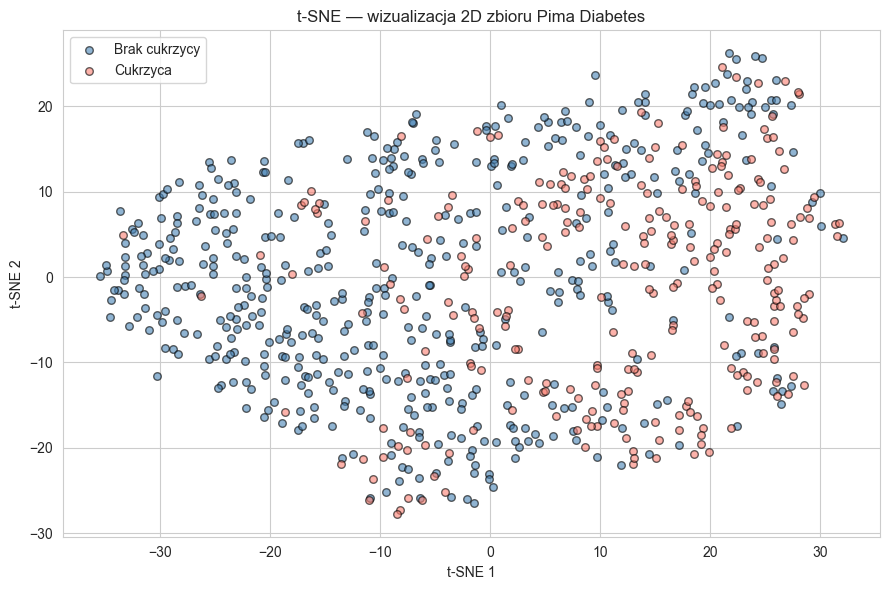

In [19]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(9, 6))
for c, label, color in [(0, 'Brak cukrzycy', 'steelblue'),
                         (1, 'Cukrzyca',     'salmon')]:
    mask = y == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=label, alpha=0.6, edgecolors='k', s=30)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title('t-SNE — wizualizacja 2D zbioru Pima Diabetes')
plt.legend()
plt.tight_layout(); plt.show()


**Wniosek z t-SNE:** klasy **nie są wyraźnie rozdzielalne** w 2D — punkty obu klas mocno się mieszają. To wyjaśnia, dlaczego osiągnięcie wysokiej accuracy (> 80%) jest trudne — granica między klasami jest nieostra, a niektóre pacjentki z normalnymi wartościami i tak rozwijają cukrzycę (czynniki genetyczne, środowiskowe poza zbiorem cech).

## 9. Ważność cech (Random Forest)

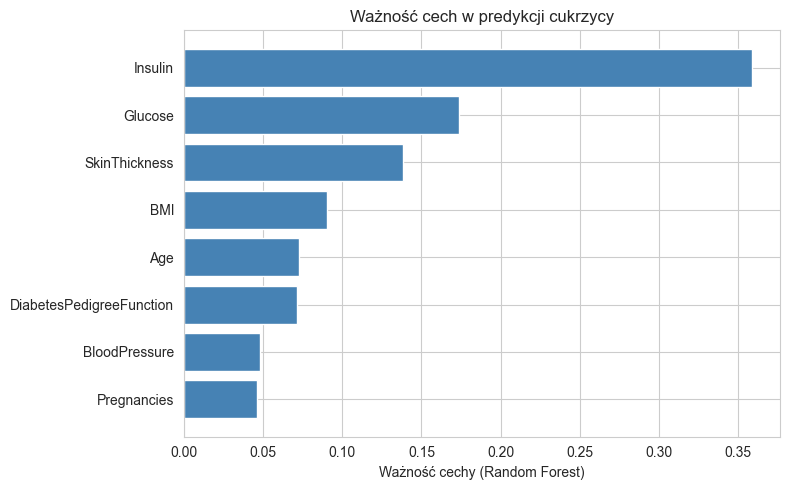

                   Cecha  Ważność
                 Insulin    0.358
                 Glucose    0.174
           SkinThickness    0.139
                     BMI    0.090
                     Age    0.073
DiabetesPedigreeFunction    0.072
           BloodPressure    0.048
             Pregnancies    0.046


In [20]:
rf = best_models['Random Forest']
fi = pd.DataFrame({'Cecha': X.columns, 'Ważność': rf.feature_importances_})
fi = fi.sort_values('Ważność', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi['Cecha'], fi['Ważność'], color='steelblue')
plt.xlabel('Ważność cechy (Random Forest)')
plt.title('Ważność cech w predykcji cukrzycy')
plt.tight_layout(); plt.show()

print(fi.sort_values('Ważność', ascending=False).round(3).to_string(index=False))


**Wnioski medyczne:** najsilniejsze predyktory cukrzycy w tym zbiorze to **`Glucose`** (zdecydowanie dominuje), **`BMI`** i **`Age`** — zgadza się to z wiedzą kliniczną (poziom glukozy na czczo, otyłość i wiek to klasyczne czynniki ryzyka cukrzycy typu 2).

## 10. Podsumowanie

| Element | Wynik |
|---|---|
| Dataset | Pima Indians Diabetes — 768 obserwacji, 8 cech, target binarny |
| Rozkład klas | ~65% (brak) / ~35% (cukrzyca) — lekka nierównowaga |
| Czyszczenie | Zera w 5 kolumnach traktowane jako braki → imputacja medianą per klasa |
| Modele | LogReg, SVM (linear+RBF), kNN, Decision Tree, Random Forest |
| Najlepszy model (przed tuningiem) | zwykle Random Forest lub Logistic Regression |
| Tuning (GridSearchCV) | 5-fold CV, metryka F1, 3 modele dostrajane |
| PCA | 2 komp. ≈ 45% wariancji (za mało do dobrej klasyfikacji, dobre do wizualizacji) |
| t-SNE | klasy częściowo przenikają się — granica nieostra |
| Najważniejsze cechy | `Glucose`, `BMI`, `Age` — zgodne z wiedzą medyczną |

**Najważniejszy wniosek:** dla zbioru Pima ~78–82% accuracy / F1 ~0.65–0.72 to typowy "sufit" osiągany na tym datasecie — ograniczenie pochodzi z samego problemu (cukrzyca ma podłoże wieloczynnikowe, a 8 cech nie wystarczy do idealnej predykcji). W diagnostyce medycznej **recall** (czułość) klasy „chorych" jest często ważniejszy niż accuracy — przeoczenie chorej pacjentki kosztuje więcej niż fałszywy alarm.